# **1. Import Libraries**

In [5]:
# --- Core Python Libraries ---
import os
import random
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# --- Image Handling ---
from PIL import Image

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Evaluation ---
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

# --- Jupyter Widgets ---
!pip install ipywidgets
import ipywidgets as widgets
from IPython.display import display

# **1.1 Initialize Path**

In [6]:
# Define the base directory for the dataset
base_path = '/kaggle/input/fruit-recognition'

# Define the paths for the training and testing data
train_path = os.path.join(base_path, 'train/train')
test_path = os.path.join(base_path, 'test/test')

# **2. Preview Data**

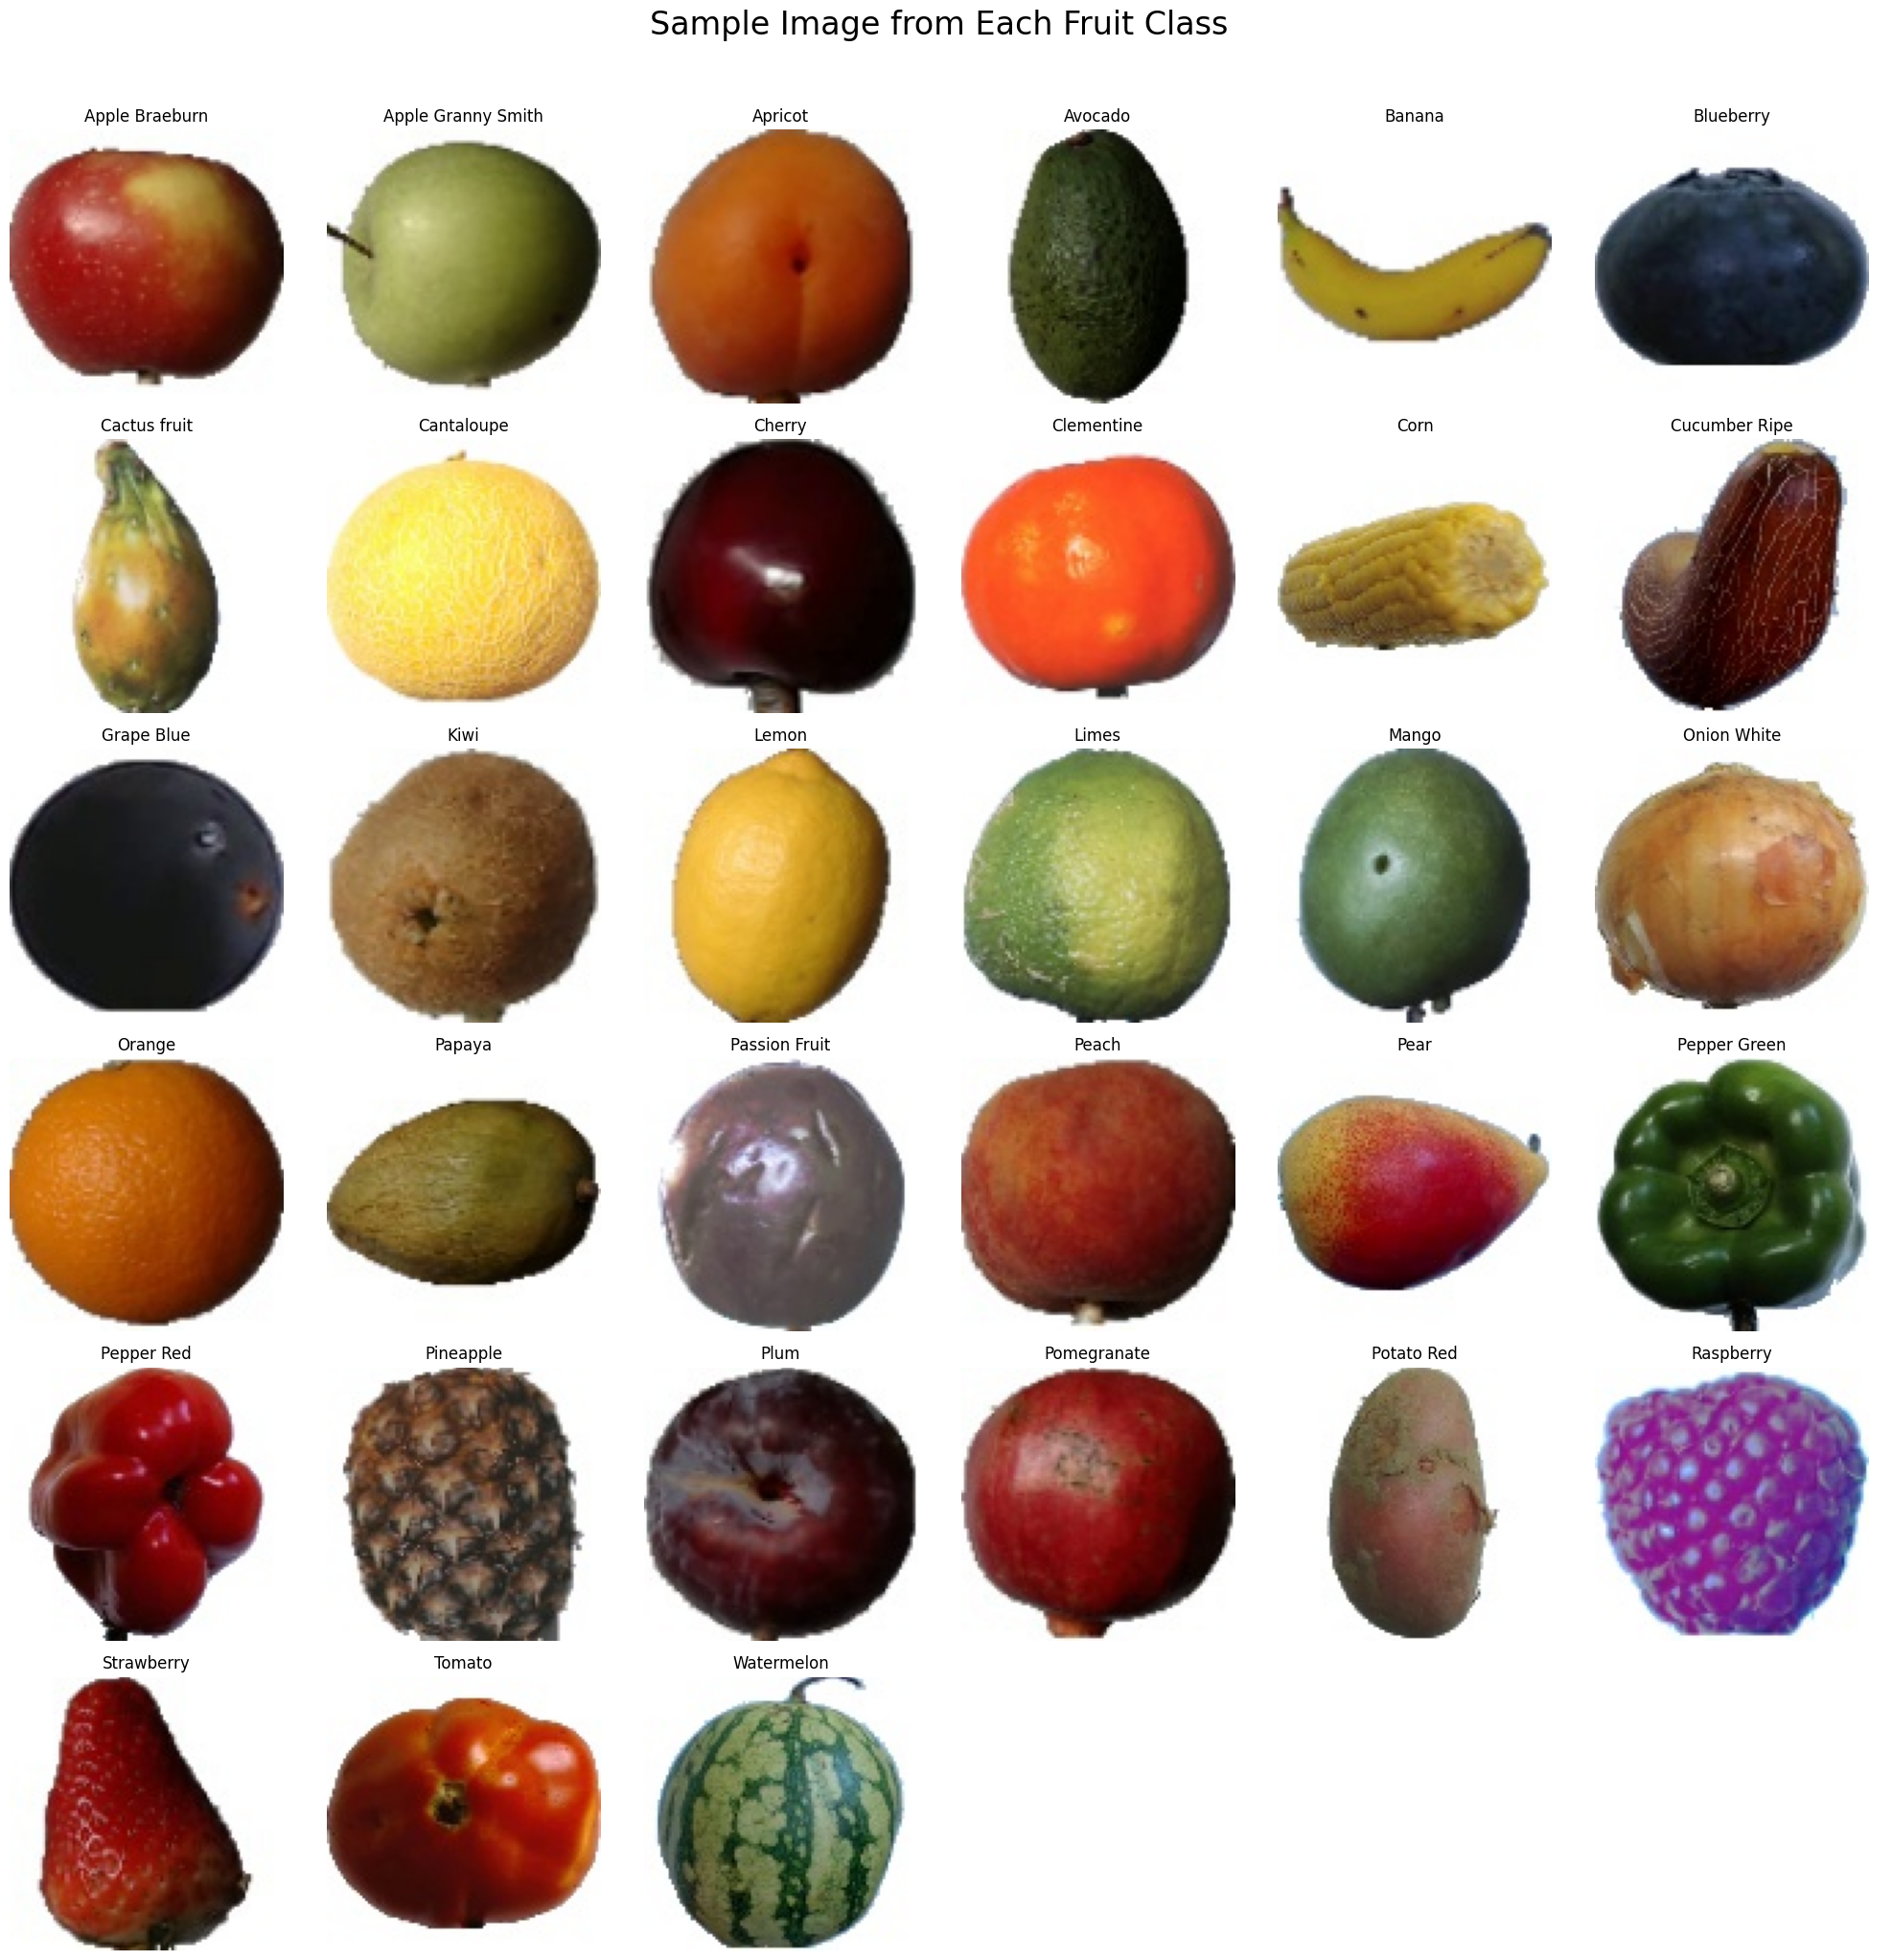

In [7]:
# Display one random sample image from each class
class_names = sorted(os.listdir(train_path))

fig, axes = plt.subplots(6, 6, figsize=(20, 20))
fig.suptitle("Sample Image from Each Fruit Class", fontsize=24, y=1.02)
axes = axes.ravel()

for i, class_name in enumerate(class_names):
    class_dir = os.path.join(train_path, class_name)
    image_files = os.listdir(class_dir)
    
    if image_files:
        image_path = os.path.join(class_dir, random.choice(image_files))
        img = mpimg.imread(image_path)
        axes[i].imshow(img)
        axes[i].set_title(class_name, fontsize=12)
        axes[i].axis("off")

for j in range(len(class_names), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# **3. Data Exploration**

In [8]:
# Get all classnames from directory
class_names = sorted(os.listdir(train_path))

print("Classes:", class_names)
print("Total number of classes:", len(class_names))

Classes: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']
Total number of classes: 33


In [9]:
# Count images per class
class_counts = {
    cls: len(os.listdir(os.path.join(train_path, cls)))
    for cls in class_names
}

# Create DataFrame sorted by count
df_counts = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])
df_counts = df_counts.sort_values(by='Count', ascending=False)
df_counts.insert(0, 'sl.no', range(1, 1 + len(df_counts)))

print("Image counts per class:")
print(df_counts.to_string(index=False))

# Total images
total_images = df_counts['Count'].sum()
print(f"\nTotal number of images: {total_images}")

Image counts per class:
 sl.no              Class  Count
     1         Grape Blue    984
     2             Tomato    738
     3               Pear    696
     4         Pepper Red    666
     5     Apple Braeburn    492
     6             Papaya    492
     7              Lemon    492
     8              Peach    492
     9             Cherry    492
    10         Cantaloupe    492
    11        Pomegranate    492
    12         Strawberry    492
    13            Apricot    492
    14 Apple Granny Smith    492
    15          Pineapple    490
    16          Raspberry    490
    17      Passion Fruit    490
    18              Mango    490
    19              Limes    490
    20         Clementine    490
    21       Cactus fruit    490
    22             Banana    490
    23             Orange    479
    24         Watermelon    475
    25               Kiwi    466
    26          Blueberry    462
    27               Corn    450
    28         Potato Red    450
    29             

# **4. Define and Load Data using Pipeline**

# 4.1 Preprocessing and Splitting Dataset 

In [10]:
# Image dimensions and batch size
img_width, img_height = 100, 100
batch_size = 32

# Data generator with normalization and train/validation split
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data (80%)
train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation data (20%)
validation_generator = datagen.flow_from_directory(
    train_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Summary
print(f"Training images: {train_generator.n}")
print(f"Validation images: {validation_generator.n}")
print(f"Number of classes: {train_generator.num_classes}")

Found 13493 images belonging to 33 classes.
Found 3361 images belonging to 33 classes.
Training images: 13493
Validation images: 3361
Number of classes: 33


# 4.2 Data Augmentation

In [11]:
# Image dimensions and batch size
img_width, img_height = 100, 100
batch_size = 32

# Data generator with augmentation and validation split
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

# Training data (80%)
train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation data (20%)
validation_generator = datagen.flow_from_directory(
    train_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Summary
print(f"Training images: {train_generator.n}")
print(f"Validation images: {validation_generator.n}")
print(f"Number of classes: {train_generator.num_classes}")

Found 13493 images belonging to 33 classes.
Found 3361 images belonging to 33 classes.
Training images: 13493
Validation images: 3361
Number of classes: 33


# **5. Model Evaluation**

In [12]:
# Number of classes and image dimensions
num_classes = train_generator.num_classes
img_width, img_height = 100, 100

# Use MirroredStrategy for multi-GPU or robust device placement
strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    model = tf.keras.Sequential([
        # Convolutional blocks
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # Flatten and fully connected layers
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

2026-05-08 04:14:03.400676: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │        16,929 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,306,849 (4.99 MB)

 Trainable params: 1,306,849 (4.99 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Define the number of training epochs
epochs = 20

# Early stopping callback to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',   
    patience=3,           
    restore_best_weights=True
)

# Start training
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    callbacks=[early_stop]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
421/421 ━━━━━━━━━━━━━━━━━━━━ 198s 465ms/step - accuracy: 0.4238 - loss: 1.8663 - val_accuracy: 0.8890 - val_loss: 0.3314
Epoch 2/20
  1/421 ━━━━━━━━━━━━━━━━━━━━ 2:06 302ms/step - accuracy: 0.8438 - loss: 0.3276

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


421/421 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.8438 - loss: 0.3276 - val_accuracy: 0.8935 - val_loss: 0.3305
Epoch 3/20
421/421 ━━━━━━━━━━━━━━━━━━━━ 173s 411ms/step - accuracy: 0.8563 - loss: 0.4022 - val_accuracy: 0.9220 - val_loss: 0.2184
Epoch 4/20
421/421 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.8750 - loss: 0.2904 - val_accuracy: 0.9342 - val_loss: 0.1854
Epoch 5/20
421/421 ━━━━━━━━━━━━━━━━━━━━ 174s 413ms/step - accuracy: 0.9094 - loss: 0.2518 - val_accuracy: 0.9667 - val_loss: 0.1026
Epoch 6/20
421/421 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.8750 - loss: 0.2724 - val_accuracy: 0.9604 - val_loss: 0.1096
Epoch 7/20
421/421 ━━━━━━━━━━━━━━━━━━━━ 178s 407ms/step - accuracy: 0.9332 - loss: 0.1837 - val_accuracy: 0.9780 - val_loss: 0.0738
Epoch 8/20
421/421 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 1.0000 - loss: 0.0308 - val_accuracy: 0.9744 - val_loss: 0.0742
Epoch 9/20
421/421 ━━━━━━━━━━━━━━━━━━━━ 180s 406ms/step - accuracy: 0.9487 - loss: 0.1509 - val

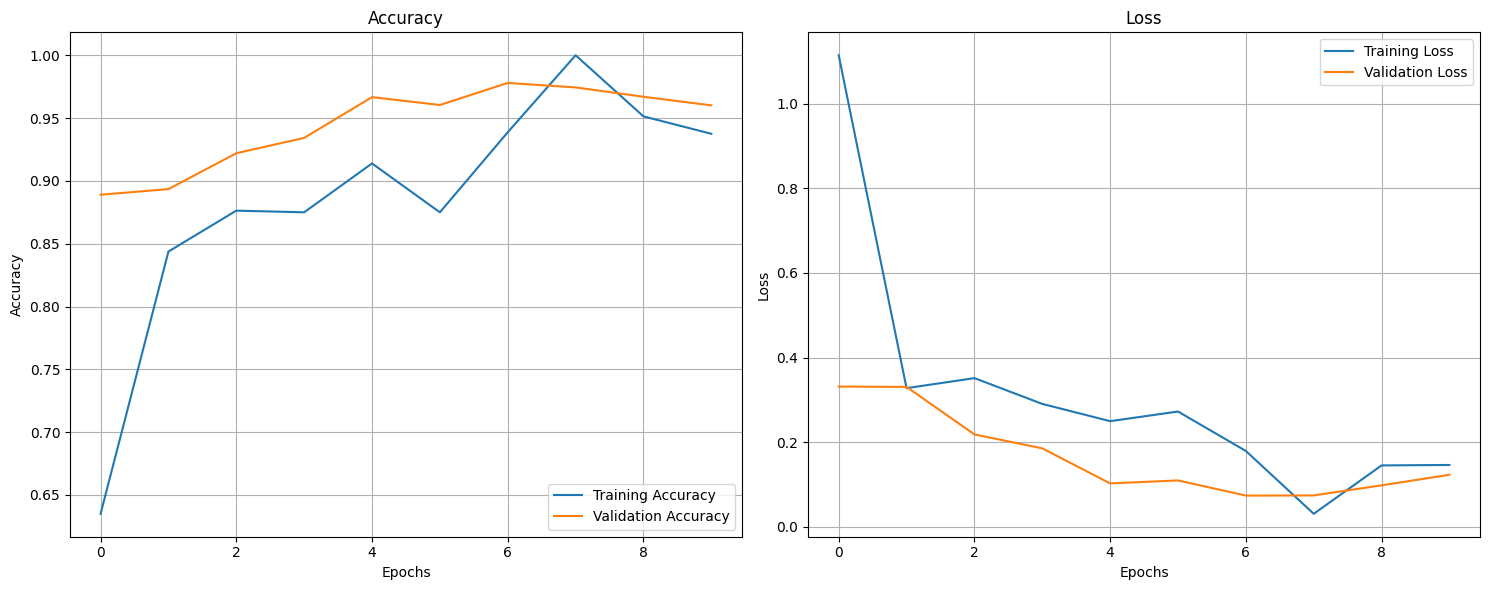

In [14]:
# Extract metrics from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Plot training and validation accuracy & loss
plt.figure(figsize=(15, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
# Get the final validation metrics
final_accuracy = history.history['val_accuracy'][-1]
final_loss = history.history['val_loss'][-1]

print(f"Final Validation Accuracy: {final_accuracy:.4f}")
print(f"Final Validation Loss: {final_loss:.4f}")

Final Validation Accuracy: 0.9601
Final Validation Loss: 0.1230


In [16]:
# Get the true labels and predicted labels for the validation set
validation_labels = validation_generator.classes
validation_steps = validation_generator.samples // validation_generator.batch_size
predictions = model.predict(validation_generator, steps=validation_steps)
predicted_labels = np.argmax(predictions, axis=1)

# Get the class labels from the generator
class_labels = list(validation_generator.class_indices.keys())

# Generate and print the classification report
report = classification_report(validation_labels[:len(predicted_labels)], predicted_labels, target_names=class_labels)
print("\nClassification Report:\n", report)

105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 200ms/step

Classification Report:
                     precision    recall  f1-score   support

    Apple Braeburn       0.86      0.98      0.92        98
Apple Granny Smith       1.00      1.00      1.00        98
           Apricot       1.00      0.99      0.99        98
           Avocado       1.00      1.00      1.00        85
            Banana       1.00      0.96      0.98        98
         Blueberry       0.98      1.00      0.99        92
      Cactus fruit       0.96      0.93      0.94        98
        Cantaloupe       0.97      0.95      0.96        98
            Cherry       1.00      0.98      0.99        98
        Clementine       0.98      1.00      0.99        98
              Corn       0.95      1.00      0.97        90
     Cucumber Ripe       0.99      1.00      0.99        78
        Grape Blue       1.00      0.99      0.99       196
              Kiwi       1.00      0.89      0.94        93
             Lemon       0.95 

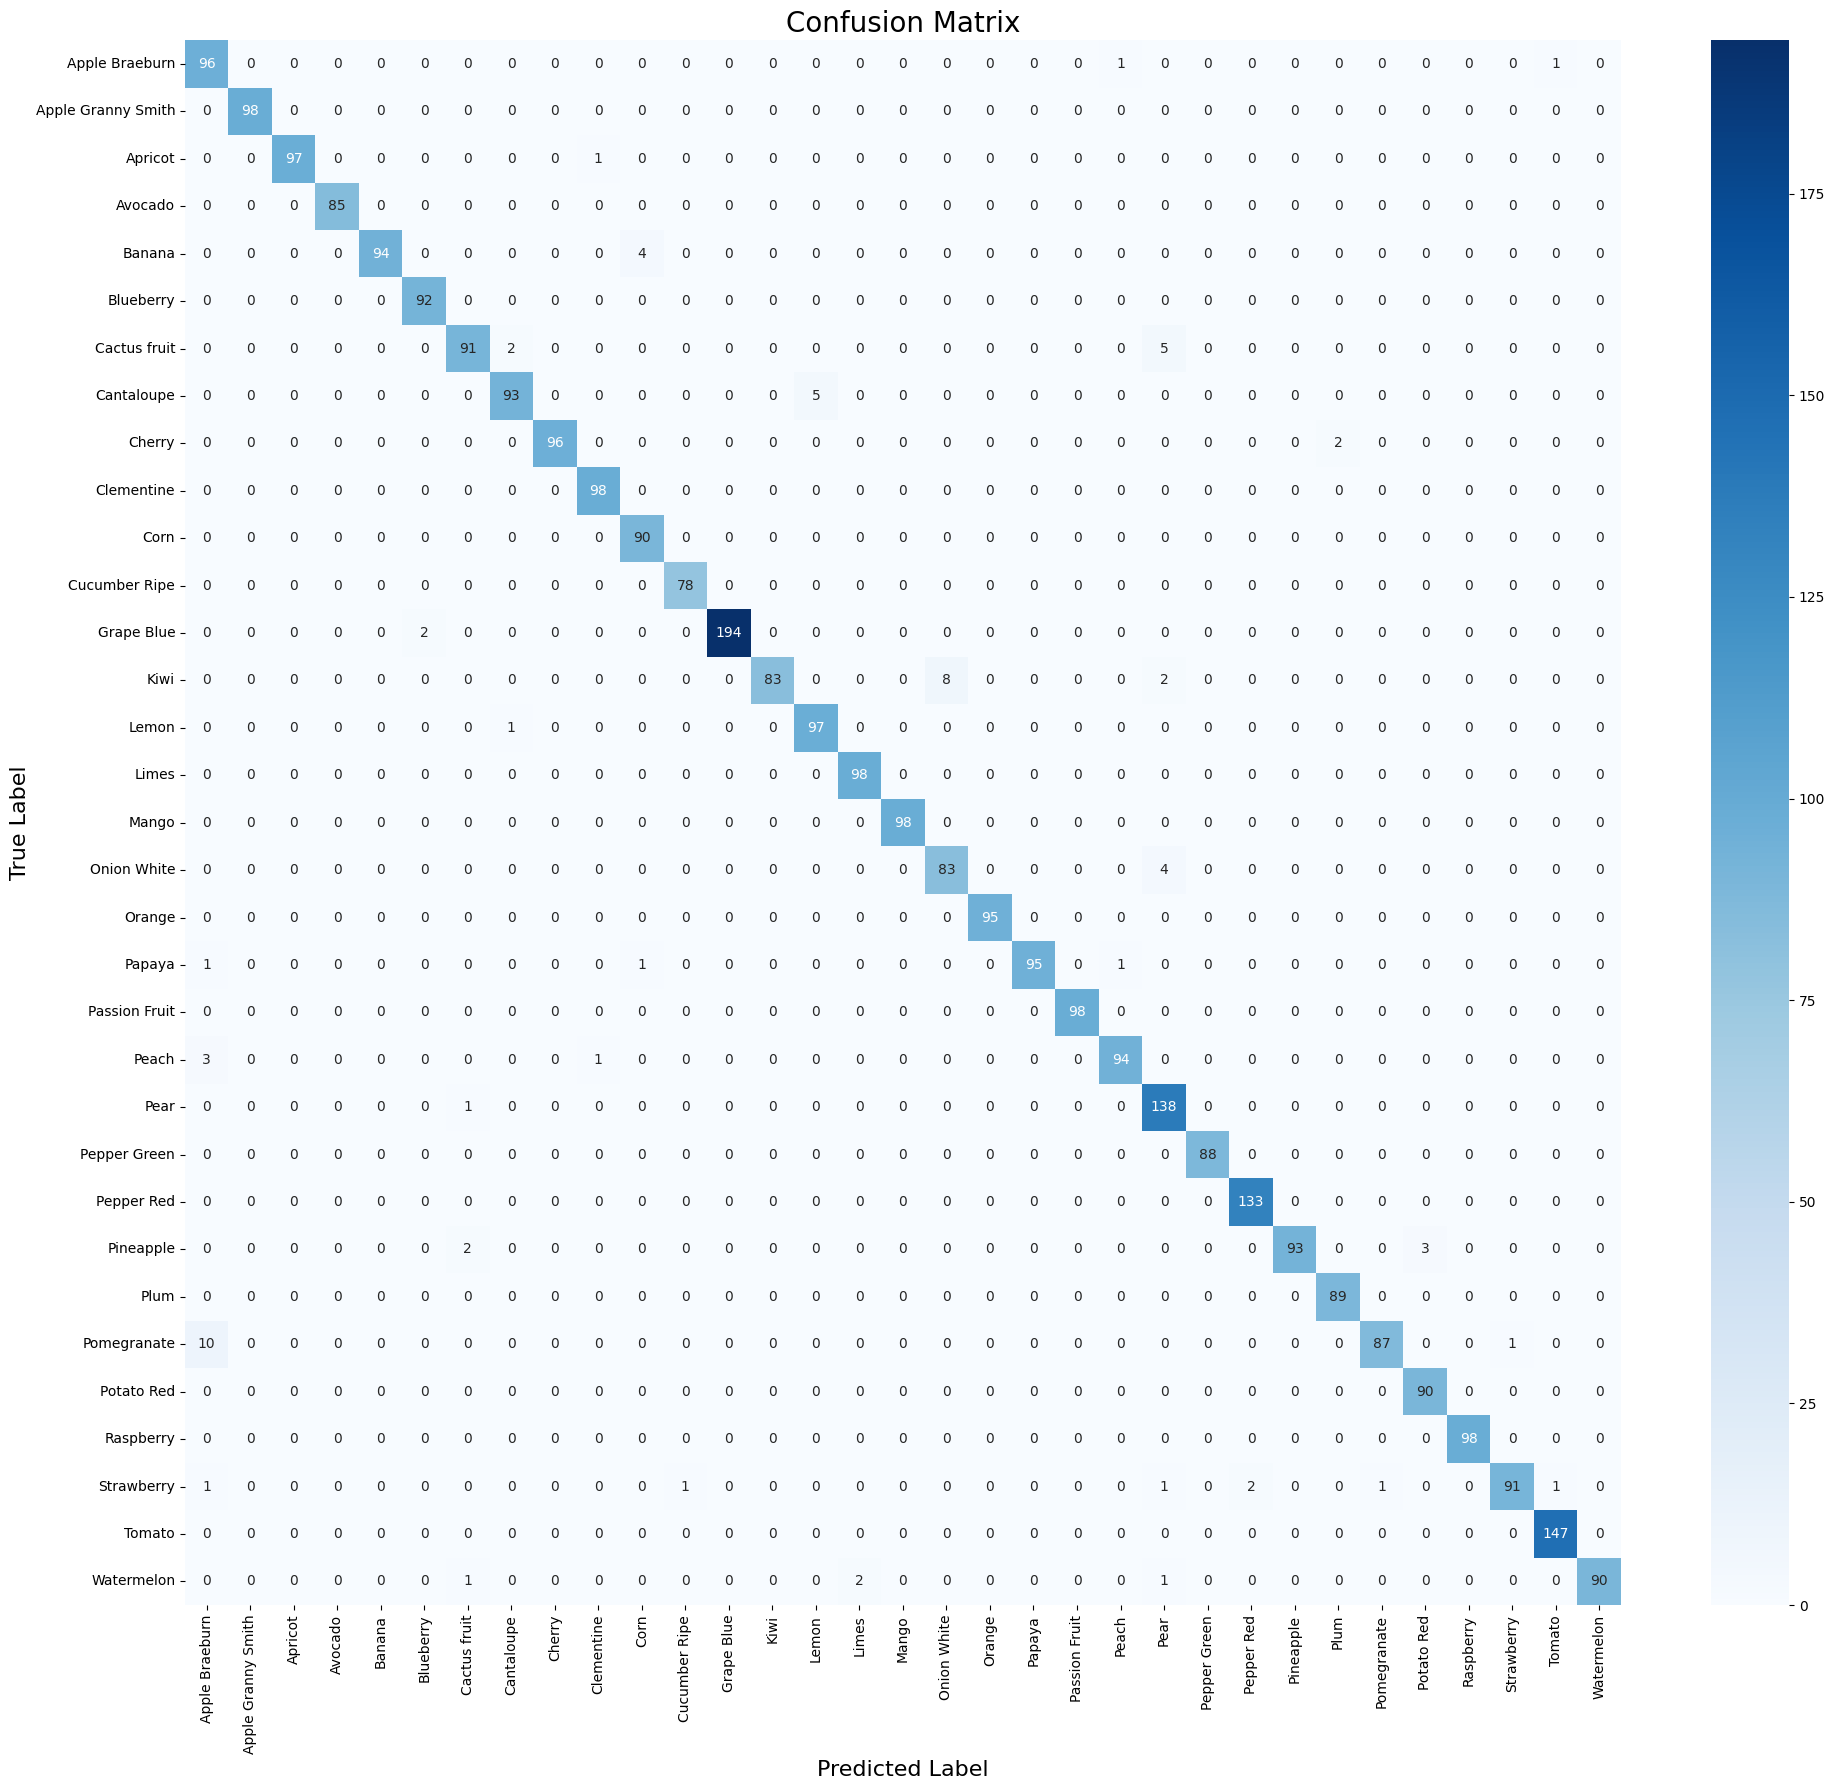

In [17]:
# Generate the confusion matrix
cm = confusion_matrix(validation_labels[:len(predicted_labels)], predicted_labels)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix', fontsize=20)
plt.xlabel('Predicted Label', fontsize=16)
plt.ylabel('True Label', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# **6. Test model with Unseen Data**

In [18]:
# Save the model in the HDF5 (.h5) format
model.save('my_fruit_model.h5')
print("Model saved successfully as 'my_fruit_model.h5'.")

Model saved successfully as 'my_fruit_model.h5'.


In [19]:
# -------------------------------
# FORCE CPU (avoid transfer manager errors)
# -------------------------------
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# -------------------------------
# LOAD MODEL
# -------------------------------
model_path = "/kaggle/working/my_fruit_model.h5"
model = load_model(model_path, compile=False)

# -------------------------------
# CLASS LABELS
# -------------------------------
class_labels = [
    'Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana',
    'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn',
    'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango',
    'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear',
    'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate',
    'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon'
]

# -------------------------------
# IMAGE PREPROCESSING
# -------------------------------
def preprocess_image(image_path, target_size=(100, 100)):
    """Load image, resize, normalize and expand dimensions for prediction."""
    img = Image.open(image_path).convert("RGB")
    img = img.resize(target_size)
    img_array = np.array(img).astype("float32") / 255.0
    return np.expand_dims(img_array, axis=0)

# -------------------------------
# PREDICTION FUNCTION
# -------------------------------
def predict_image(img_path):
    """Predict and display image with label and confidence."""
    x = preprocess_image(img_path)
    x = tf.convert_to_tensor(x)

    with tf.device("/CPU:0"):
        preds = model(x, training=False).numpy()

    idx = np.argmax(preds, axis=1)[0]
    label = class_labels[idx]
    conf = preds[0][idx] * 100

    # Display image with predicted label
    plt.imshow(Image.open(img_path))
    plt.axis("off")
    plt.title(f"Predicted: {label} ({conf:.2f}%)", fontsize=14)
    plt.show()

    # Print prediction info
    print(f"📂 File: {os.path.basename(img_path)}")
    print(f"✅ Prediction: {label} ({conf:.2f}%)\n")

# -------------------------------
# TEST IMAGES
# -------------------------------
test_path = "/kaggle/input/fruit-recognition/test/test"
image_files = sorted([f for f in os.listdir(test_path) if f.lower().endswith(".jpg")])

# -------------------------------
# WIDGETS
# -------------------------------
dropdown = widgets.Dropdown(
    options=image_files,
    description="Choose Image:",
    layout=widgets.Layout(width="60%")
)

count_box = widgets.BoundedIntText(
    value=1,
    min=1,
    max=len(image_files),
    step=1,
    description="How many:",
    layout=widgets.Layout(width="30%")
)

button = widgets.Button(description="Predict ✅", button_style="success")
output = widgets.Output()

def on_submit(b):
    output.clear_output()
    with output:
        start_index = image_files.index(dropdown.value)
        num = min(count_box.value, len(image_files) - start_index)
        selected_files = image_files[start_index:start_index+num]
        for f in selected_files:
            predict_image(os.path.join(test_path, f))

button.on_click(on_submit)

# -------------------------------
# DISPLAY WIDGETS
# -------------------------------
display(widgets.VBox([dropdown, count_box, button, output]))

---

## 💡 Found this Notebook Helpful?

If this notebook helped you in any way, please consider **upvoting** 👍.  
Your support motivates me to keep sharing more useful content! 🚀

---

